# Autocorrelation in Time Series

Autocorrelation measures how a time series correlates with itself at different time lags. It reveals patterns, periodicities, and temporal dependencies in data.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Autocorrelation Function (ACF)

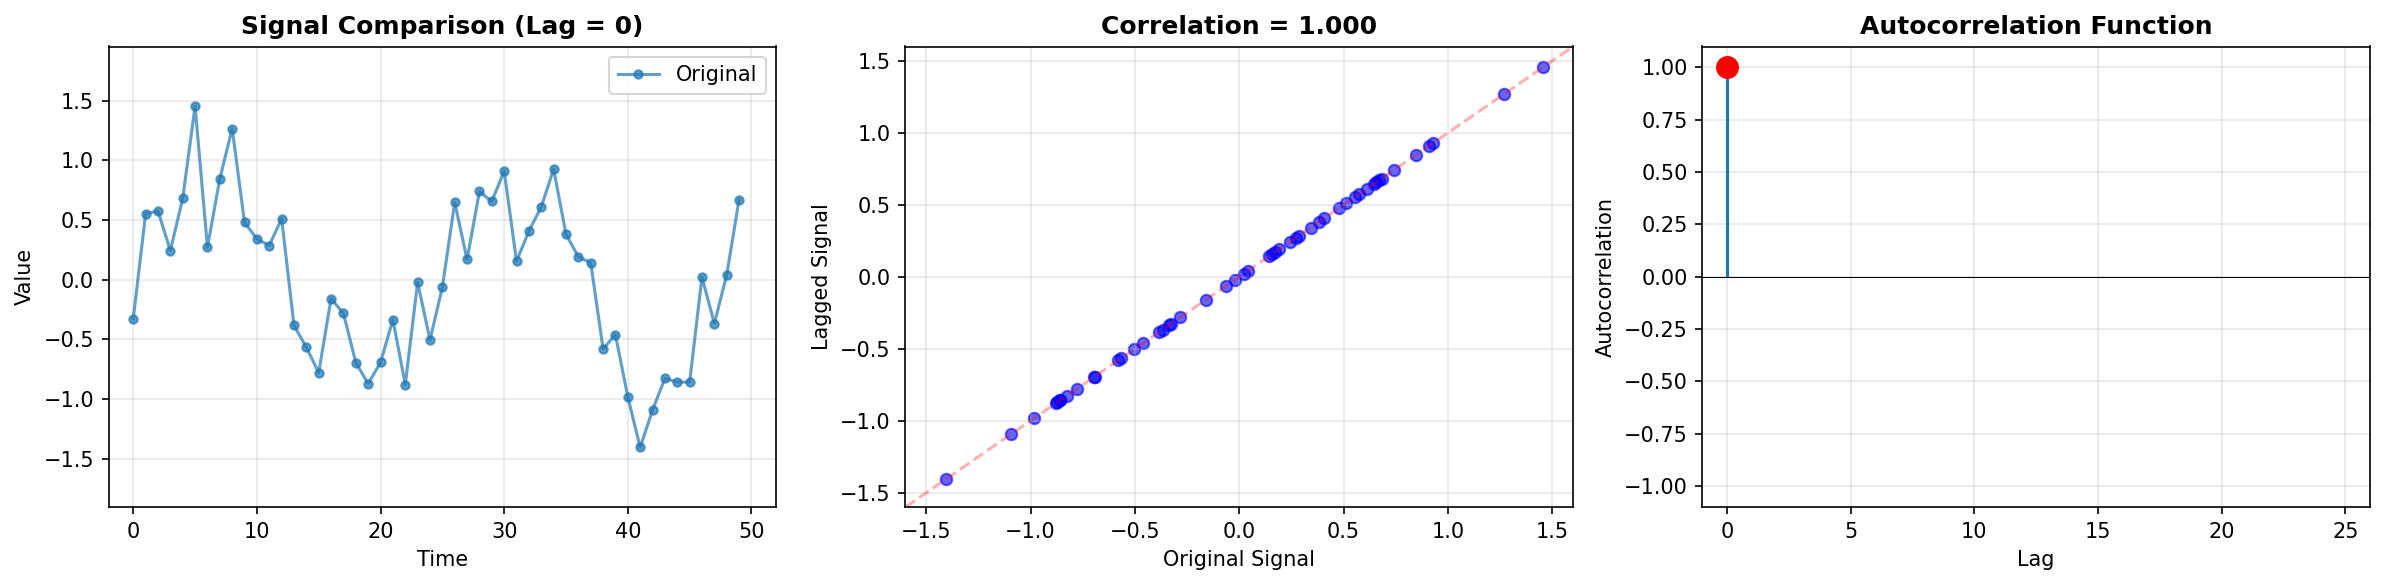

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Create animation data
np.random.seed(123)
anim_n = 50
anim_signal = np.sin(np.linspace(0, 4*np.pi, anim_n)) + 0.3*np.random.normal(0, 1, anim_n)

# Calculate ACF for all lags
max_lag = 25
acf_values = []
for lag in range(max_lag):
    if lag == 0:
        acf_values.append(1.0)
    else:
        corr = np.corrcoef(anim_signal[lag:], anim_signal[:-lag])[0, 1]
        acf_values.append(corr)

# Create the animation
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

def animate(lag):
    for ax in axes:
        ax.clear()
    
    # Left: Time series with shift
    axes[0].plot(range(anim_n), anim_signal, 'o-', markersize=4, label='Original', alpha=0.7)
    if lag > 0:
        shifted = np.concatenate([np.full(lag, np.nan), anim_signal[:-lag]])
        axes[0].plot(range(anim_n), shifted, 's-', markersize=4, label=f'Lag {lag}', alpha=0.7)
    axes[0].set_title(f'Signal Comparison (Lag = {lag})', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Time')
    axes[0].set_ylabel('Value')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_xlim(-2, anim_n+2)
    axes[0].set_ylim(anim_signal.min()-0.5, anim_signal.max()+0.5)
    
    # Middle: Scatter plot
    if lag == 0:
        axes[1].scatter(anim_signal, anim_signal, alpha=0.6, s=30, c='blue')
        corr = 1.0
    else:
        axes[1].scatter(anim_signal[lag:], anim_signal[:-lag], alpha=0.6, s=30, c='blue')
        p = np.polyfit(anim_signal[lag:], anim_signal[:-lag], 1)
        corr = acf_values[lag]

        srt = np.argsort(anim_signal)
        axes[1].plot(anim_signal[srt], np.polyval(p, anim_signal[srt]), 'b', alpha=abs(acf_values[lag]))

    
    axes[1].set_title(f'Correlation = {corr:.3f}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Original Signal')
    axes[1].set_ylabel(f'Lagged Signal')
    axes[1].grid(alpha=0.3)
    lim = max(abs(anim_signal.min()), abs(anim_signal.max())) * 1.1
    axes[1].set_xlim(-lim, lim)
    axes[1].set_ylim(-lim, lim)
    axes[1].plot([-lim, lim], [-lim, lim], 'r--', alpha=0.3)
    
    # Right: ACF plot (accumulated)
    axes[2].stem(range(lag+1), acf_values[:lag+1], basefmt=' ')
    axes[2].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    axes[2].plot(lag, acf_values[lag], 'ro', markersize=10, zorder=5)
    axes[2].set_title('Autocorrelation Function', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Lag')
    axes[2].set_ylabel('Autocorrelation')
    axes[2].grid(alpha=0.3)
    axes[2].set_xlim(-1, max_lag+1)
    axes[2].set_ylim(-1.1, 1.1)
    
    plt.tight_layout()

# Create animation
anim = FuncAnimation(fig, animate, frames=max_lag, interval=300, repeat=True)

anim.save('figs/autocorrelation_animation.gif', 
          writer='pillow', 
          fps=2,           # Slower animation
          dpi=80,          # Lower resolution for smaller file
          )

# # Display animation
# HTML(anim.to_jshtml())

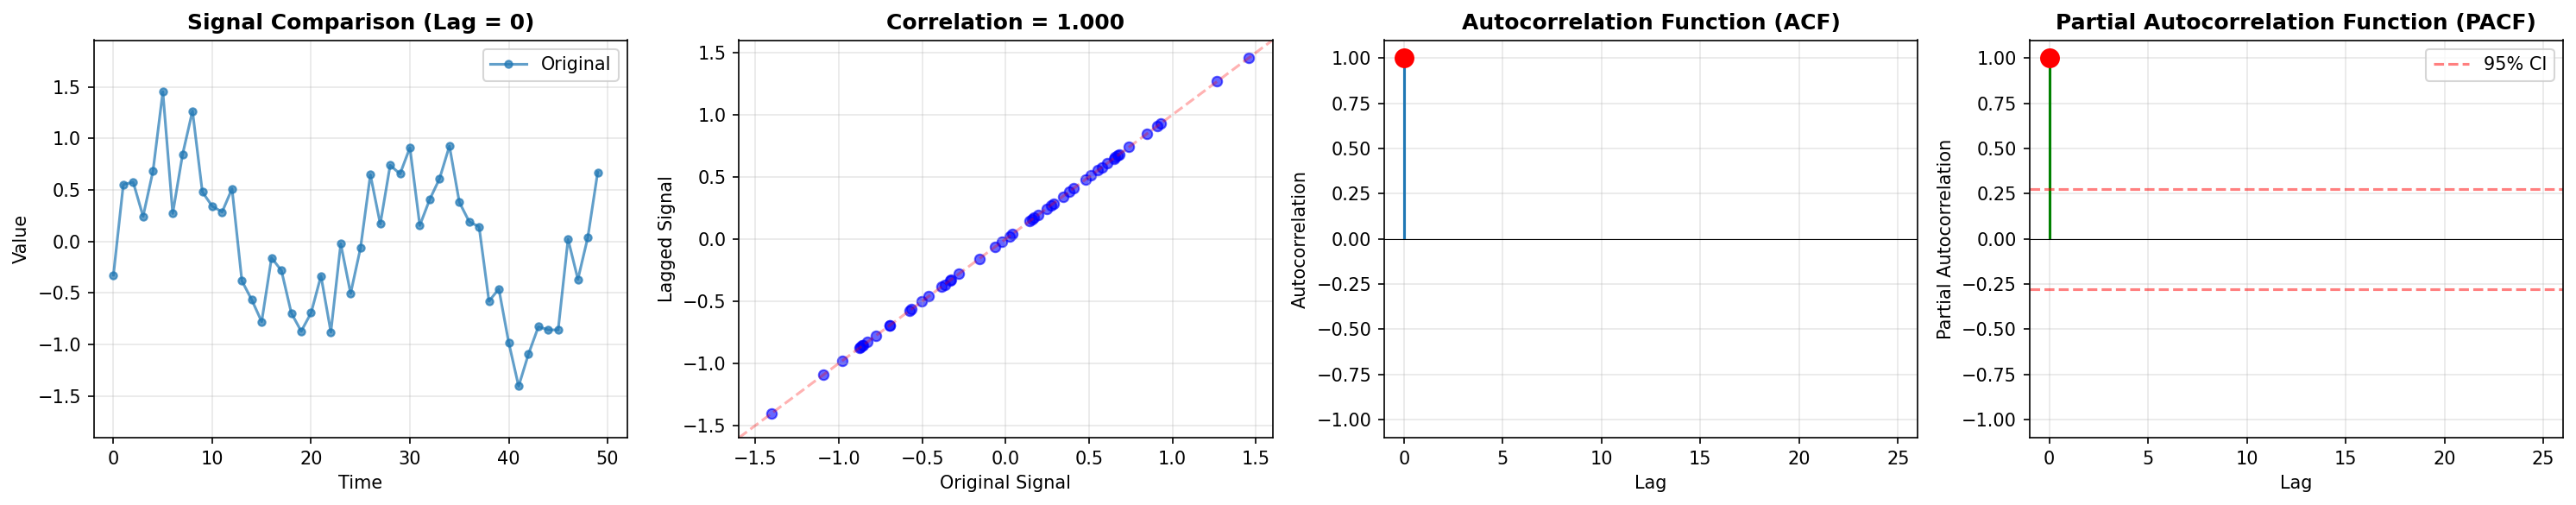

In [4]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from statsmodels.tsa.stattools import pacf

# Create animation data
np.random.seed(123)
anim_n = 50
anim_signal = np.sin(np.linspace(0, 4*np.pi, anim_n)) + 0.3*np.random.normal(0, 1, anim_n)

# Calculate ACF for all lags
max_lag = 25
acf_values = []
for lag in range(max_lag):
    if lag == 0:
        acf_values.append(1.0)
    else:
        corr = np.corrcoef(anim_signal[lag:], anim_signal[:-lag])[0, 1]
        acf_values.append(corr)

# Calculate PACF using statsmodels
pacf_values = pacf(anim_signal, nlags=max_lag-1, method='ols')

# Create the animation with 4 panels
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

def animate(lag):
    for ax in axes:
        ax.clear()
    
    # Panel 1: Time series with shift
    axes[0].plot(range(anim_n), anim_signal, 'o-', markersize=4, label='Original', alpha=0.7)
    if lag > 0:
        shifted = np.concatenate([np.full(lag, np.nan), anim_signal[:-lag]])
        axes[0].plot(range(anim_n), shifted, 's-', markersize=4, label=f'Lag {lag}', alpha=0.7)
    axes[0].set_title(f'Signal Comparison (Lag = {lag})', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Time')
    axes[0].set_ylabel('Value')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_xlim(-2, anim_n+2)
    axes[0].set_ylim(anim_signal.min()-0.5, anim_signal.max()+0.5)
    
    # Panel 2: Scatter plot
    if lag == 0:
        axes[1].scatter(anim_signal, anim_signal, alpha=0.6, s=30, c='blue')
        corr = 1.0
    else:
        axes[1].scatter(anim_signal[lag:], anim_signal[:-lag], alpha=0.6, s=30, c='blue')
        p = np.polyfit(anim_signal[lag:], anim_signal[:-lag], 1)
        corr = acf_values[lag]

        srt = np.argsort(anim_signal)
        axes[1].plot(anim_signal[srt], np.polyval(p, anim_signal[srt]), 'b', alpha=abs(acf_values[lag]))

    
    axes[1].set_title(f'Correlation = {corr:.3f}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Original Signal')
    axes[1].set_ylabel(f'Lagged Signal')
    axes[1].grid(alpha=0.3)
    lim = max(abs(anim_signal.min()), abs(anim_signal.max())) * 1.1
    axes[1].set_xlim(-lim, lim)
    axes[1].set_ylim(-lim, lim)
    axes[1].plot([-lim, lim], [-lim, lim], 'r--', alpha=0.3)
    
    # Panel 3: ACF plot (accumulated)
    axes[2].stem(range(lag+1), acf_values[:lag+1], basefmt=' ')
    axes[2].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    axes[2].plot(lag, acf_values[lag], 'ro', markersize=10, zorder=5)
    axes[2].set_title('Autocorrelation Function (ACF)', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Lag')
    axes[2].set_ylabel('Autocorrelation')
    axes[2].grid(alpha=0.3)
    axes[2].set_xlim(-1, max_lag+1)
    axes[2].set_ylim(-1.1, 1.1)
    
    # Panel 4: PACF plot (accumulated)
    axes[3].stem(range(lag+1), pacf_values[:lag+1], basefmt=' ', linefmt='green', markerfmt='go')
    axes[3].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    axes[3].plot(lag, pacf_values[lag], 'ro', markersize=10, zorder=5)
    axes[3].set_title('Partial Autocorrelation Function (PACF)', fontsize=12, fontweight='bold')
    axes[3].set_xlabel('Lag')
    axes[3].set_ylabel('Partial Autocorrelation')
    axes[3].grid(alpha=0.3)
    axes[3].set_xlim(-1, max_lag+1)
    axes[3].set_ylim(-1.1, 1.1)
    
    # Add significance bands for PACF (approximate 95% confidence interval)
    n_obs = len(anim_signal)
    confidence_interval = 1.96 / np.sqrt(n_obs)
    axes[3].axhline(y=confidence_interval, color='red', linestyle='--', alpha=0.5, label='95% CI')
    axes[3].axhline(y=-confidence_interval, color='red', linestyle='--', alpha=0.5)
    if lag == 0:
        axes[3].legend()
    
    plt.tight_layout()

# Create animation
anim = FuncAnimation(fig, animate, frames=max_lag, interval=300, repeat=True)

anim.save('figs/autocorrelation_pacf_animation.gif', 
          writer='pillow', 
          fps=2,           # Slower animation
          dpi=80,          # Lower resolution for smaller file
          )

# Display animation
# HTML(anim.to_jshtml())

## Example 1: White Noise (No Autocorrelation)

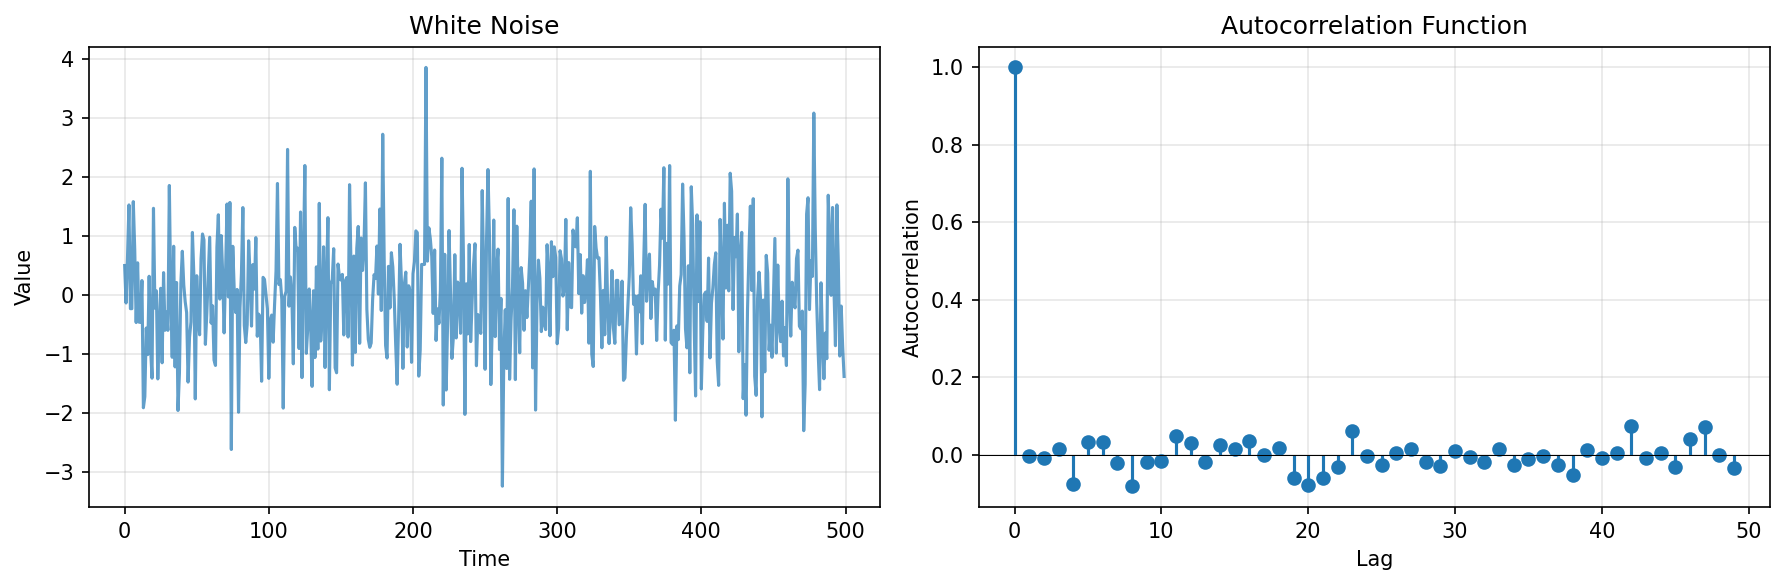

In [15]:
np.random.seed(42)
n = 500
t = np.arange(n)

# White noise: independent random values
white_noise = np.random.normal(0, 1, n)

# Compute autocorrelation
acf_white = np.correlate(white_noise - white_noise.mean(), 
                         white_noise - white_noise.mean(), 
                         mode='full') / (white_noise.std()**2 * n)
acf_white = acf_white[n-1:]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(t, white_noise, alpha=0.7)
ax1.set_xlabel('Time')
ax1.set_ylabel('Value')
ax1.set_title('White Noise')
ax1.grid(alpha=0.3)

ax2.stem(np.arange(50), acf_white[:50], basefmt=' ')
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Lag')
ax2.set_ylabel('Autocorrelation')
ax2.set_title('Autocorrelation Function')
ax2.grid(alpha=0.3)

plt.tight_layout()

## Example 2: Periodic Signal (Strong Autocorrelation)

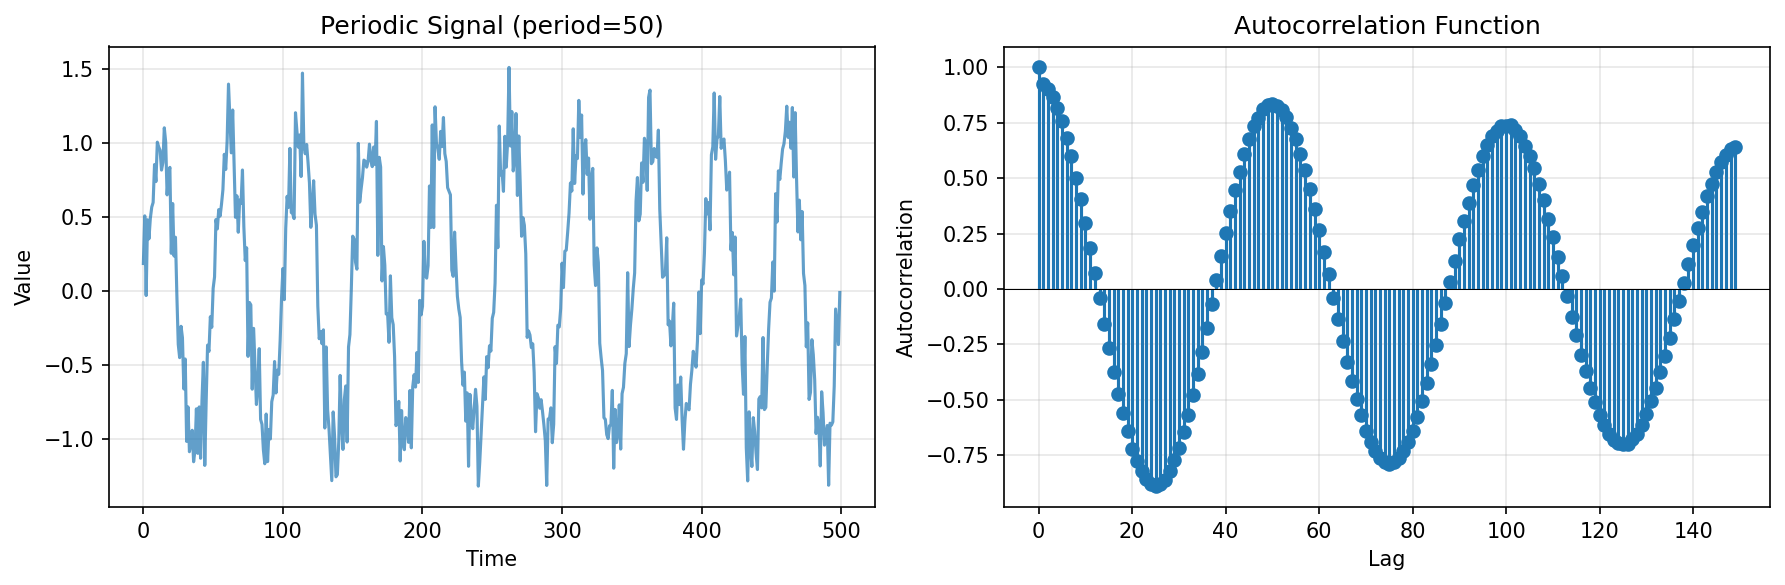

In [16]:
# Sinusoidal signal with period 50
period = 50
periodic = np.sin(2 * np.pi * t / period) + 0.2 * np.random.normal(0, 1, n)

# Compute autocorrelation
acf_periodic = np.correlate(periodic - periodic.mean(), 
                            periodic - periodic.mean(), 
                            mode='full') / (periodic.std()**2 * n)
acf_periodic = acf_periodic[n-1:]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(t, periodic, alpha=0.7)
ax1.set_xlabel('Time')
ax1.set_ylabel('Value')
ax1.set_title(f'Periodic Signal (period={period})')
ax1.grid(alpha=0.3)

ax2.stem(np.arange(150), acf_periodic[:150], basefmt=' ')
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Lag')
ax2.set_ylabel('Autocorrelation')
ax2.set_title('Autocorrelation Function')
ax2.grid(alpha=0.3)

plt.tight_layout()

## Example 3: Random Walk (Persistent Autocorrelation)

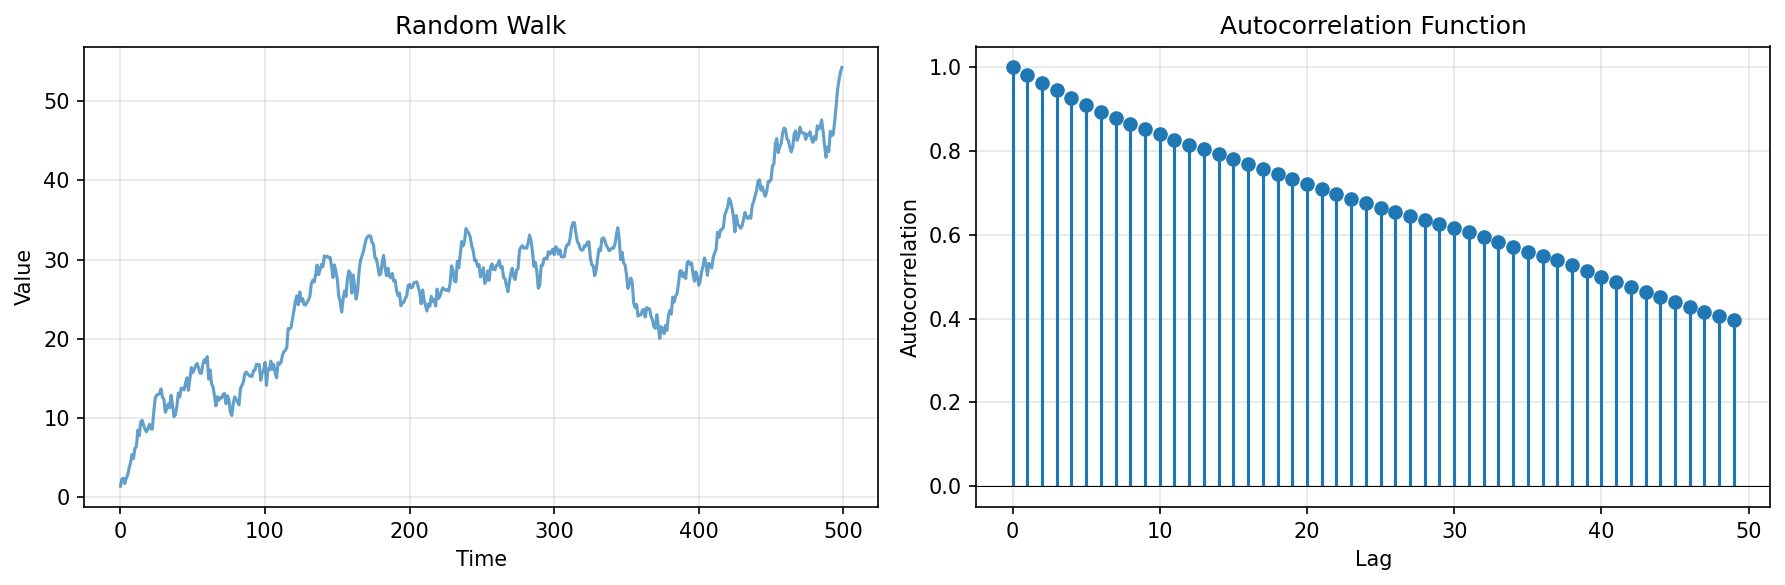

In [5]:
# Random walk: cumulative sum of random steps
random_walk = np.cumsum(np.random.normal(0, 1, n))

# Compute autocorrelation
acf_walk = np.correlate(random_walk - random_walk.mean(), 
                        random_walk - random_walk.mean(), 
                        mode='full') / (random_walk.std()**2 * n)
acf_walk = acf_walk[n-1:]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(t, random_walk, alpha=0.7)
ax1.set_xlabel('Time')
ax1.set_ylabel('Value')
ax1.set_title('Random Walk')
ax1.grid(alpha=0.3)

ax2.stem(np.arange(50), acf_walk[:50], basefmt=' ')
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Lag')
ax2.set_ylabel('Autocorrelation')
ax2.set_title('Autocorrelation Function')
ax2.grid(alpha=0.3)

plt.tight_layout()

## Example 4: Exponentially Decaying Autocorrelation (AR(1) Process)

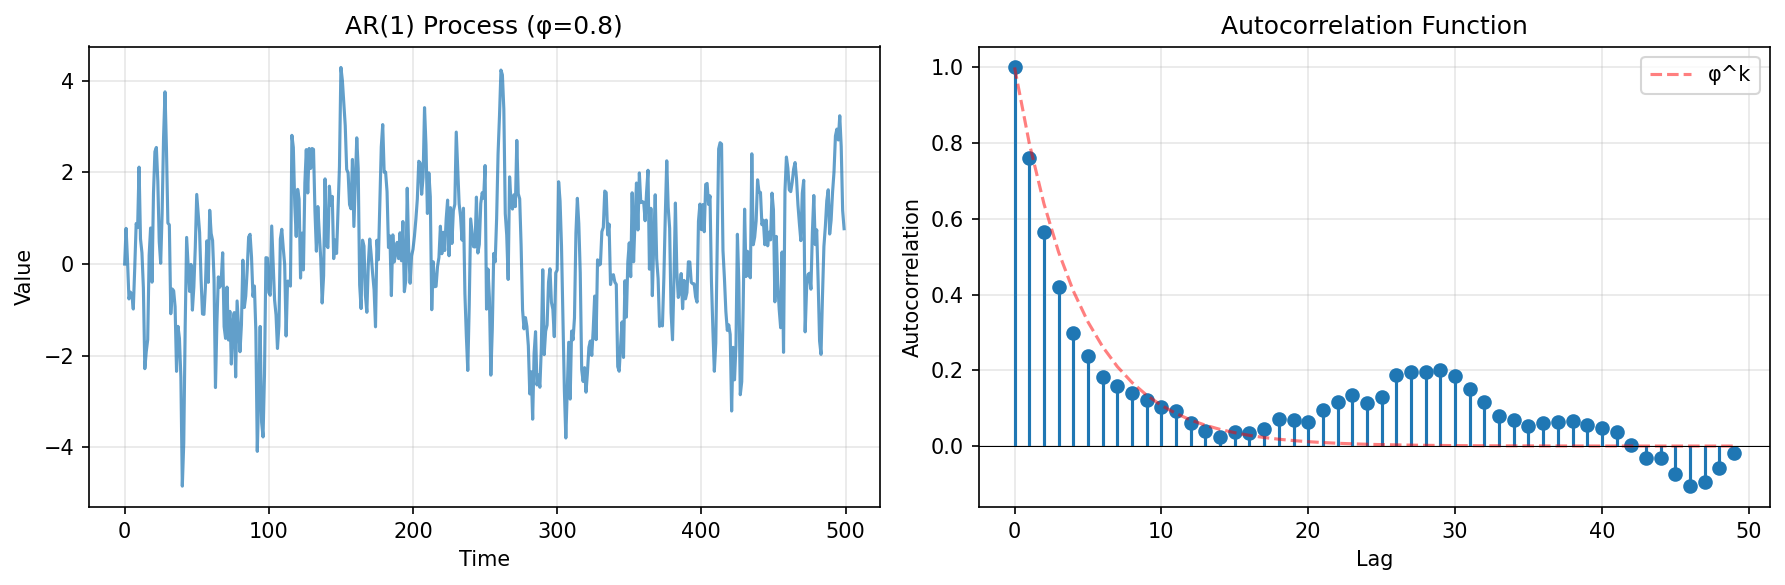

In [6]:
# AR(1) process: x[t] = φ * x[t-1] + ε[t]
phi = 0.8
ar1 = np.zeros(n)
for i in range(1, n):
    ar1[i] = phi * ar1[i-1] + np.random.normal(0, 1)

# Compute autocorrelation
acf_ar1 = np.correlate(ar1 - ar1.mean(), 
                       ar1 - ar1.mean(), 
                       mode='full') / (ar1.std()**2 * n)
acf_ar1 = acf_ar1[n-1:]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(t, ar1, alpha=0.7)
ax1.set_xlabel('Time')
ax1.set_ylabel('Value')
ax1.set_title(f'AR(1) Process (φ={phi})')
ax1.grid(alpha=0.3)

ax2.stem(np.arange(50), acf_ar1[:50], basefmt=' ')
ax2.plot(np.arange(50), phi**np.arange(50), 'r--', alpha=0.5, label=f'φ^k')
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Lag')
ax2.set_ylabel('Autocorrelation')
ax2.set_title('Autocorrelation Function')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()